# Notebook For Figure S8 Method Paper

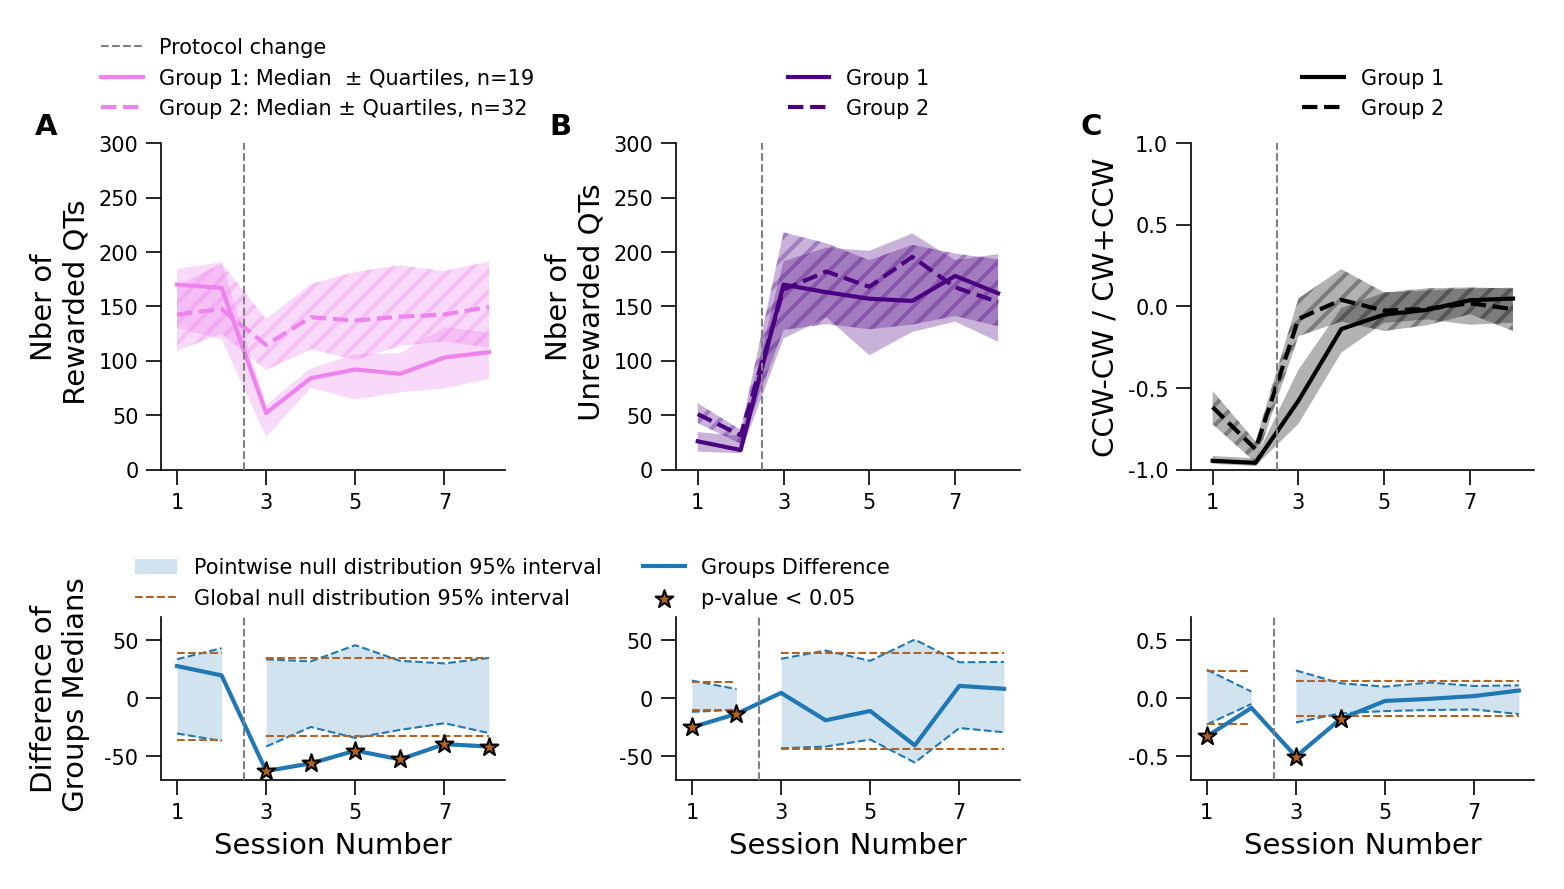

In [19]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS13.png")
display(img)


# 1. Importing necessary libraries and general functions  

In [3]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import numpy as np
import pickle
import similaritymeasures as sm
from scipy.stats import permutation_test

plt.style.use('paper.mplstyle')



In [4]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [5]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

path_to_data_folder_1='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data/'
path_to_data_folder_2='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data/'
# path_to_data_folder_1='/home/david/MyLocalData/4TowersTask_MethodPaper/Group1Data'
# path_to_data_folder_2='/home/david/MyLocalData/4TowersTask_MethodPaper/Group2Data'

# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/AurelienData/'

# Analysing the entire group of mice
mice_to_analyse_1 = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]

mice_to_analyse_2 = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008','MOU5130',
                   'MOU5131', 'MOU5136', 'MOU5140', 'MOU5142', 'MOU5143', 'MOU5144', 'MOU5145', 'MOU5148', 'MOU5149', 'MOU5158']


# Verify that all folders in mice_to_analyse_1 and mice_to_analyse_2 are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse_1 if not os.path.isdir(os.path.join(path_to_data_folder_1, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders from group 1 are present in data folder.")

missing_folders = [mouse for mouse in mice_to_analyse_2 if not os.path.isdir(os.path.join(path_to_data_folder_2, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders from group 2 are present in data folder.")


# Print the number of mice, the list of mice
print(f'{len(mice_to_analyse_1)+len(mice_to_analyse_2)} {"mice" if len(mice_to_analyse_1)+len(mice_to_analyse_2) > 1 else "mouse"} will be analysed.')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes_1 = [18,26]
first_and_last_session_indexes_2 = [32,40]

# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set. TODO: Should reformulate this 
session_index_offset_1 = first_and_last_session_indexes_1[0]
session_index_offset_2 = first_and_last_session_indexes_2[0]

# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

All mice folders from group 1 are present in data folder.
All mice folders from group 2 are present in data folder.
51 mice will be analysed.


# 3. Chosing illustration mice and sessions  

In [6]:
# Chose the 2 mice that are highlighted in statistics across figures
illustration_mice_1 = ['MOUEml1_8', 'MOUEml1_5']
illustration_mice_2 = ['MOU3974', 'MOU4561']

# Set the limits of the x-axis on the statistics plots
xlim_stats_1 = [0.5,8.5] #[first_and_last_session_indexes_1[0]+0.5,first_and_last_session_indexes_1[1]+0.5]
xlim_stats_2 = [0.5,8.5] #[first_and_last_session_indexes_2[0]+0.5,first_and_last_session_indexes_2[1]+0.5]


# 4. General functions

In [7]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

def filter_qts(qts):

    """
    Filter out QTs with length above threshold and during which more than 1 switch occured.

    Arguments:
        qts (list): list of QTs (in the original format from the pickle)

    return:
        (list): list of filtered QTs
    """

    filtered_qts = []

    
    for qt in qts:

        # Skip current QT if there is more than 1 switches
        if qt[3]['num_trapezeswitch']!=1:
            
            continue
        
        # Skip current QT if it is longer than a threshold length (30 cm)
        if qt[4]['epoch_distance']>30:

            continue

        # Keep current QT if it did not check the removal conditions
        filtered_qts.append(qt)

    return filtered_qts

def count_qts(qts):

    total_qts = len(qts)
    cw_qts = 0
    rewarded_qts = 0

    for qt in qts:

        if qt[3]['direction']=='CW':

            cw_qts += 1

        if qt[3]['Rewarded']:

            rewarded_qts += 1

    return total_qts, cw_qts, rewarded_qts

def compute_average_direction(points):

    """
    Compute the average direction of a trajectory portion, assuming the coordinates are in chronological order.

    Arguments:
        points (2D numpy.array): Trajectory of which the average direction will be computed

    Outputs:
        avg_diff (1D numpy.array): vector pointing to the average direction
        angle (float): angle of the vector with the x-axis 
    """
    
    diffs = np.diff(points, axis=0)
    avg_diff = np.mean(diffs, axis=0)
    angle = np.arctan2(avg_diff[1], avg_diff[0])
    return avg_diff, angle

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index):
    
    """
    Determines the rewarded direction for the session corresponding to the input index of a given mouse. 
    This index is relative to the session position in the series of analysed sessions.
    This input index can have an offset. This is usefull if the sessions series analysed does not start with the first session. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs or if both directions are rewarded.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
        
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Clockwise and Counterclockwise

        # Returns None if the rewarded direction entry in session_param_df is not recognized
        else:
            print('ERROR: Unexpected rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction


def plot_learning_curves(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], mice_to_highlight_labels=[None,None], linestyle='-', 
                         highlight_colors = ["darkorange", "green"], show_individual_mice=True, median_color='black', hatch_style='', show_xlabel=True,
                         ylabel='', main_line_label=None, tick_interval=1, index_offset=0, xlim=[None,None], ylim=[None,None], show_legend=True,
                         legend_loc=(0.05, 0.9)):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
        legend_loc (tupple, optional): Location of the legend.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    mice_to_plot = mice_list

    # Ensure that the mice to hihlight will be plotted and displayed on the legend in order
    if len(mice_to_highlight)>0:

        mice_to_plot.remove(mice_to_highlight[0])
        mice_to_plot.remove(mice_to_highlight[1])

        mice_to_plot = mice_to_highlight + mice_to_plot
    
    # Loop through each mouse and gather session data

    for mouse in mice_to_plot:

        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Check if there is a nan value in the values list and remove it to allow plotting of lines between points with values
        if sum(np.isnan(x) for x in values)>0:

            session_indices_array=np.array(session_indices)
            values_array=np.array(values)
            mask = ~np.isnan(values_array)
            session_indices=session_indices_array[mask]
            values=values_array[mask]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:

            if mouse == mice_to_highlight[0]:
                color = highlight_colors[0]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linestyle=linestyle, linewidth=0.5, 
                        markersize=1, label= mice_to_highlight_labels[0], zorder=100*len(median_color))

            elif mouse == mice_to_highlight[1]: 
                color = highlight_colors[1]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linestyle=linestyle, linewidth=0.5, 
                        markersize=1, label= mice_to_highlight_labels[1], zorder=100*len(median_color))
            
            else:
                ax.plot(np.array(session_indices)+index_offset, values, marker='o', linestyle=linestyle, linewidth=0.5, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.plot(np.array(sorted_sessions)+index_offset, median_values, alpha=1, color=median_color, linestyle=linestyle, linewidth = 1, label=main_line_label,
            zorder=50*len(median_color))
    ax.fill_between(np.array(sorted_sessions)+index_offset, lower_quartile, upper_quartile, color=median_color, alpha=0.3, hatch=hatch_style, linewidth=0)
    # yerr=[median_values-lower_quartile, upper_quartile-median_values]

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number')
    
    ax.set_ylabel(ylabel)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1+index_offset, max_index + 1+index_offset, tick_interval))

    # Apply x and y axis limits if provided
    ax.set_xlim(xlim)
    
    ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:

        ax.legend(frameon=False, loc=legend_loc )


# 5. Panel A

The next two functions are used to:
- Find the times at which QTs occured.
- Find the time at which the number of QTs becomes higher than a given threshold.

In [8]:
# Initialize dictionaries to store the various metrics for each mouse
mice_rewarded_qts_persession_1 = {mouse: [] for mouse in mice_to_analyse_1}
mice_unrewarded_qts_persession_1 = {mouse: [] for mouse in mice_to_analyse_1}
mice_cw_vs_ccw_norm_diff_persession_1 = {mouse: [] for mouse in mice_to_analyse_1}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse_1:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder_1, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[first_and_last_session_indexes_1[0]:first_and_last_session_indexes_1[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')


    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        
        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            # Append session Nan data to the respective dictionaries
            mice_cw_vs_ccw_norm_diff_persession_1[mouse].append([session_index + 1, np.nan])
            mice_rewarded_qts_persession_1[mouse].append([session_index + 1, np.nan])
            mice_unrewarded_qts_persession_1[mouse].append([session_index + 1, np.nan])
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Determine the rewarded direction for all sessions of the current mouse
        rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, first_and_last_session_indexes_1[0]+session_index)
        
        # Extract run around tower results from the session data
        epochs = session_data['all_epochs']
        qts = filter_qts(epochs['run_around_tower'])
        total_qts, cw_qts, rewarded_qts = count_qts(qts)
        ccw_qts = total_qts - cw_qts
        ccw_vs_cw_norm_diff = (ccw_qts-cw_qts)/(total_qts)

        # If reward delivery is not allowed, set to numpy.nan the metrics values concerning rewarded direction
        if rewarded_direction == 'X':
           
            # Append session data to the respective dictionaries
            mice_cw_vs_ccw_norm_diff_persession_1[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mice_rewarded_qts_persession_1[mouse].append([session_index + 1, np.nan])
            mice_unrewarded_qts_persession_1[mouse].append([session_index + 1, np.nan])

        else:        

            # Append session data to the respective dictionaries
            mice_cw_vs_ccw_norm_diff_persession_1[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mice_rewarded_qts_persession_1[mouse].append([session_index + 1, rewarded_qts])
            mice_unrewarded_qts_persession_1[mouse].append([session_index + 1, total_qts-rewarded_qts])


Mouse MOUEml1_5. There is/are 8 sessions:
['MOUEml1_5_20230430-1021', 'MOUEml1_5_20230430-1529', 'MOUEml1_5_20230501-1038', 'MOUEml1_5_20230501-1601', 'MOUEml1_5_20230502-1133', 'MOUEml1_5_20230502-1645', 'MOUEml1_5_20230503-1032', 'MOUEml1_5_20230503-1722'] 

Mouse MOUEml1_8. There is/are 8 sessions:
['MOUEml1_8_20230430-1116', 'MOUEml1_8_20230430-1621', 'MOUEml1_8_20230501-1129', 'MOUEml1_8_20230501-1651', 'MOUEml1_8_20230502-1227', 'MOUEml1_8_20230502-1740', 'MOUEml1_8_20230503-1125', 'MOUEml1_8_20230503-1812'] 

Mouse MOUEml1_11. There is/are 8 sessions:
['MOUEml1_11_20230430-1213', 'MOUEml1_11_20230430-1724', 'MOUEml1_11_20230501-1223', 'MOUEml1_11_20230501-1753', 'MOUEml1_11_20230502-1326', 'MOUEml1_11_20230502-1842', 'MOUEml1_11_20230503-1228', 'MOUEml1_11_20230503-1909'] 

Mouse MOUEml1_12. There is/are 8 sessions:
['MOUEml1_12_20230430-1228', 'MOUEml1_12_20230430-1738', 'MOUEml1_12_20230501-1238', 'MOUEml1_12_20230501-1808', 'MOUEml1_12_20230502-1340', 'MOUEml1_12_20230502-185

In [9]:
# Initialize dictionaries to store the various metrics for each mouse
mice_rewarded_qts_persession_2 = {mouse: [] for mouse in mice_to_analyse_2}
mice_unrewarded_qts_persession_2 = {mouse: [] for mouse in mice_to_analyse_2}
mice_cw_vs_ccw_norm_diff_persession_2 = {mouse: [] for mouse in mice_to_analyse_2}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse_2:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder_2, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[first_and_last_session_indexes_2[0]:first_and_last_session_indexes_2[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Deterine the first unique rewarded direction of the session series
    first_rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, 4)

    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        
        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            # Append session Nan data to the respective dictionaries
            mice_cw_vs_ccw_norm_diff_persession_2[mouse].append([session_index + 1, np.nan])
            mice_rewarded_qts_persession_2[mouse].append([session_index + 1, np.nan])
            mice_unrewarded_qts_persession_2[mouse].append([session_index + 1, np.nan])
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Determine the rewarded direction for all sessions of the current mouse
        rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, first_and_last_session_indexes_2[0]+session_index)

        # Extract run around tower results from the session data
        epochs = session_data['all_epochs']
        qts = filter_qts(epochs['run_around_tower'])
        total_qts, cw_qts, rewarded_qts = count_qts(qts)
        ccw_qts = total_qts - cw_qts
        ccw_vs_cw_norm_diff = (ccw_qts-cw_qts)/(total_qts)

        # If reward delivery is not allowed, set to numpy.nan the metrics values concerning rewards

        if rewarded_direction == 'X':
           
            # Append session data to the respective dictionaries
            mice_cw_vs_ccw_norm_diff_persession_2[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mice_rewarded_qts_persession_2[mouse].append([session_index + 1, np.nan])
            mice_unrewarded_qts_persession_2[mouse].append([session_index + 1, np.nan])

        elif first_rewarded_direction == 'CCW':

            # Append session data to the respective dictionaries
            mice_cw_vs_ccw_norm_diff_persession_2[mouse].append([session_index + 1, -ccw_vs_cw_norm_diff])
            mice_rewarded_qts_persession_2[mouse].append([session_index + 1, rewarded_qts])
            mice_unrewarded_qts_persession_2[mouse].append([session_index + 1, total_qts-rewarded_qts])

        else:        

            # Append session data to the respective dictionaries
            mice_cw_vs_ccw_norm_diff_persession_2[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mice_rewarded_qts_persession_2[mouse].append([session_index + 1, rewarded_qts])
            mice_unrewarded_qts_persession_2[mouse].append([session_index + 1, total_qts-rewarded_qts])


Mouse MOU3974. There is/are 8 sessions:
['MOU3974_20230321-1140', 'MOU3974_20230321-1711', 'MOU3974_20230325-1314', 'MOU3974_20230325-1715', 'MOU3974_20230326-1338', 'MOU3974_20230326-1744', 'MOU3974_20230327-1219', 'MOU3974_20230327-1724'] 

Mouse MOU3975. There is/are 8 sessions:
['MOU3975_20230321-1153', 'MOU3975_20230321-1725', 'MOU3975_20230325-1327', 'MOU3975_20230325-1729', 'MOU3975_20230326-1353', 'MOU3975_20230326-1759', 'MOU3975_20230327-1234', 'MOU3975_20230327-1739'] 

Mouse MOU3987. There is/are 8 sessions:
['MOU3987_20230321-1109', 'MOU3987_20230321-1640', 'MOU3987_20230325-1245', 'MOU3987_20230325-1644', 'MOU3987_20230326-1309', 'MOU3987_20230326-1714', 'MOU3987_20230327-1143', 'MOU3987_20230327-1655'] 

Mouse MOU3988. There is/are 8 sessions:
['MOU3988_20230321-1123', 'MOU3988_20230321-1654', 'MOU3988_20230325-1258', 'MOU3988_20230325-1658', 'MOU3988_20230326-1323', 'MOU3988_20230326-1728', 'MOU3988_20230327-1156', 'MOU3988_20230327-1709'] 

Mouse MOU3991. There is/are 

## Panel A

In [10]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_1 = plt.subplot(row1[0])

    plot_learning_curves(mice_rewarded_qts_persession_1, ax_1, mice_to_highlight=illustration_mice_1, show_individual_mice=False, linestyle='-',
                         median_color= 'violet', show_xlabel = False, ylim=[0,300], ylabel='Total nber of QTs',
                         main_line_label=f'Median rewarded QTs \u00B1 Quartiles, n1={len(mice_to_analyse_1)}', tick_interval=2, index_offset=0, show_legend=True)

    plot_learning_curves(mice_rewarded_qts_persession_2, ax_1, mice_to_highlight=illustration_mice_2, show_individual_mice=False, linestyle='--',
                         median_color= 'violet', hatch_style='/////', show_xlabel = False, ylim=[0,300], ylabel='Total nber of QTs',
                         main_line_label=f'Median rewarded QTs \u00B1 Quartiles, n2={len(mice_to_analyse_2)}', tick_interval=2, index_offset=0, show_legend=True)


In [11]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_1 = plt.subplot(row1[0])

    plot_learning_curves(mice_unrewarded_qts_persession_1, ax_1, mice_to_highlight=illustration_mice_1, show_individual_mice=False, linestyle='-',
                         median_color= 'indigo', show_xlabel = False, ylim=[0,300], ylabel='Total nber of QTs',
                         main_line_label='Median unrewarded QTs \u00B1 Quartiles', tick_interval=2, index_offset=0, show_legend=True)

    plot_learning_curves(mice_unrewarded_qts_persession_2, ax_1, mice_to_highlight=illustration_mice_2, show_individual_mice=False, linestyle='--',
                         median_color= 'indigo', hatch_style='/////', show_xlabel = False, ylim=[0,300], ylabel='Total nber of QTs',
                         main_line_label='Median unrewarded QTs \u00B1 Quartiles', tick_interval=2, index_offset=0, show_legend=True)


In [12]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row2 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_2 = plt.subplot(row2[0])

    plot_learning_curves(mice_cw_vs_ccw_norm_diff_persession_1, ax_2, mice_to_highlight=illustration_mice_1, linestyle='-', show_individual_mice=False,
                         show_xlabel = False, ylim=[-1,1], ylabel='CW-CCW / CW+CCW', tick_interval=2, index_offset=0, main_line_label='Median \u00B1 Quartiles',
                         show_legend=True, legend_loc=(0.05,0.58))

    plot_learning_curves(mice_cw_vs_ccw_norm_diff_persession_2, ax_2, mice_to_highlight=illustration_mice_2, linestyle='--', hatch_style='/////',
                         show_individual_mice=False, show_xlabel = False, ylim=[-1,1], ylabel='CW-CCW / CW+CCW', tick_interval=2, index_offset=0,
                         main_line_label='Median \u00B1 Quartiles', show_legend=True, legend_loc=(0.05,0.58))


# 6. Panel B

In [13]:
def statistic(sample_1, sample_2, axis):

    """
    Compute the difference of the median of two samples of values.

    sample_1 (numpy.ndarray): first sample
    sample_2 (numpy.ndarray): second sample
    axis (int): axis along which to compute the medians
    """

    return np.nanmedian(sample_1, axis=axis) - np.nanmedian(sample_2, axis=axis)


def plot_group_metric_difference(mice_metric_persession_1, mice_metric_persession_2, ax, alternative = 'two-sided', permutation_type='independent', show_xlabel = True, ylim = None, ylabel = None,
                                 show_legend = True, legend_loc = (0.05, 0.9), tick_interval = 2):
    
    """
    Perform a permutation statistical test between two set of values for each sessions. 
    Then plots the correpsonding null distribution median and +- 2.5% intervals; alongside with the 
    difference between mice_metric_persession_1 and mice_metric_persession_2 average, for each sessions.

    mice_metric_persession_1 (dict): first set of values, a dictionnary with a key for each mouse, each key containing a list of session number with their corresponding metric values
    mice_metric_persession_2 (dict): first set of values with the same format as the first one
    ax (matplotlib.axes.Axes): ax object on which to plot
    alternative (str, optional): alternative hypothesis according to which the p-value is computed 
    permutation_type (str, optional): type of permutations used in the permutation test
    show_xlabel (bool, optional): if True, display the x axis label
    ylim (list, optional): y-axis limits
    ylabel (str, optional): y axis label
    median_label (str, optional): label of the null distribution average line 
    interval_label (str, optional): label of the null distribution +-47.5% interval around the average
    data_label (str, optional): label of the difference between the two original groups
    legend_loc (list, optional): localisation of the legend box
    tick_interval (int, optional): interval between x-axis ticks

    """

    # Initialize lists that will contain the statistics per sessions
    null_median_persession = []
    # null_std_deviation_persession = []
    lower_bounds_persession = []
    upper_bounds_persession = []
    
    data_median_diff_list = []
    # p_value_list = []

    # Compute the number of sessions
    number_of_sessions = len(mice_metric_persession_1[list(mice_metric_persession_1.keys())[0]])
    global_null_distribution = 0

    # Iterate on every sessions
    for i in range(number_of_sessions):

        # Extract only values per sessions
        group_1_metric_list = [mice_metric_persession_1[mouse][i][1] for mouse in list(mice_metric_persession_1.keys())]
        group_2_metric_list = [mice_metric_persession_2[mouse][i][1] for mouse in list(mice_metric_persession_2.keys())]

        # Perform the permutation test on group_1_metric_list and group_2_metric_list
        res = permutation_test((group_1_metric_list, group_2_metric_list), statistic, vectorized=True, alternative=alternative, n_resamples=100, permutation_type = permutation_type)

        # Extract the null distribution values genertaed by the test, then use it to compute the median and standard deviation of the null distribution
        # Then store those values
        null_distribution = res.null_distribution
        global_null_distribution = np.vstack((global_null_distribution,res.null_distribution)) if i>0 else res.null_distribution
        null_median_persession.append(np.median(null_distribution))
        # null_std_deviation_persession.append(np.std(null_distribution))
        lower_bounds_persession.append(np.percentile(null_distribution,2.5))
        upper_bounds_persession.append(np.percentile(null_distribution,97.5))

        # Compute the difference of the medians of the two original samples
        data_median_diff_list.append(statistic(group_1_metric_list,group_2_metric_list,0))

        # Print and store the p-value resulting from the permutation test
        print(f"Session {i+1}    p-value = {res.pvalue}")
        # p_value_list.append(res.pvalue)

    pre_global_lower_bounds = np.percentile(global_null_distribution[:2,:],2.5)
    pre_global_upper_bounds = np.percentile(global_null_distribution[:2,:],97.5)
    post_global_lower_bounds = np.percentile(global_null_distribution[2:,:],2.5)
    post_global_upper_bounds = np.percentile(global_null_distribution[2:,:],97.5)
    
    # Convert the null distribution median, standard deviation and p-value per session in a numpy array
    null_median_persession = np.array(null_median_persession)
    data_median_diff_list = np.array(data_median_diff_list)
    
    # null_std_deviation_persession = np.array(null_std_deviation_persession)   
    # p_value_list = np.array(p_value_list)

    # Find sessions where p-value is <0.05
    # significant_data_median_diff_list = np.where(p_value_list<0.05, np.array(data_median_diff_list), np.nan)
    pre_change_significant_data_median_diff_list = np.where(np.logical_or(np.array(data_median_diff_list[:2])<pre_global_lower_bounds,
                                                               np.array(data_median_diff_list[:2])>pre_global_upper_bounds),
                                                               np.array(data_median_diff_list[:2]), np.nan)
    
    post_change_significant_data_median_diff_list = np.where(np.logical_or(np.array(data_median_diff_list[2:])<post_global_lower_bounds,
                                                               np.array(data_median_diff_list[2:])>post_global_upper_bounds),
                                                               np.array(data_median_diff_list[2:]), np.nan)

    # Plot the null distribution median and +- 2.5% intervals for each session
    ax.fill_between(np.arange(number_of_sessions)[:2]+1, lower_bounds_persession[:2], upper_bounds_persession[:2],
                    alpha=0.2, label='Pointwise null distribution 95% interval', color='#1f77b4', linewidth=0)
    ax.fill_between(np.arange(number_of_sessions)[2:]+1, lower_bounds_persession[2:], upper_bounds_persession[2:],
                    alpha=0.2, color='#1f77b4', linewidth=0)

    ax.plot(np.arange(number_of_sessions)[:2]+1, lower_bounds_persession[:2],
            np.arange(number_of_sessions)[:2]+1, upper_bounds_persession[:2],
                    alpha=1, color='#1f77b4', linewidth=0.5, linestyle='--')
    
    ax.plot(np.arange(number_of_sessions)[2:]+1, lower_bounds_persession[2:],
            np.arange(number_of_sessions)[2:]+1, upper_bounds_persession[2:],
                    alpha=1, color='#1f77b4', linewidth=0.5, linestyle='--')
    
    # 

#     ax.fill_between(np.arange(number_of_sessions)[:2]+1, np.ones(number_of_sessions)[:2]*np.mean(lower_bounds_persession[:2]), np.ones(number_of_sessions)[:2]*np.mean(upper_bounds_persession[:2]),
#                     alpha=0.3, label='Global null distribution 95% interval', color='#b4621f', linewidth=0)
    
#     ax.fill_between(np.arange(number_of_sessions)[2:]+1, np.ones(number_of_sessions)[2:]*np.mean(lower_bounds_persession[2:]), np.ones(number_of_sessions)[2:]*np.mean(upper_bounds_persession[2:]),
#                     alpha=0.3, color="#b4621f", linewidth=0)

    ax.plot(np.arange(number_of_sessions)[:2]+1, np.ones(number_of_sessions)[:2]*pre_global_lower_bounds,
            alpha=1, label='Global null distribution 95% interval', color='#b4621f', linewidth=0.5, linestyle='--')
    
    ax.plot(np.arange(number_of_sessions)[:2]+1, np.ones(number_of_sessions)[:2]*pre_global_upper_bounds,
            alpha=1, color='#b4621f', linewidth=0.5, linestyle='--')

    ax.plot(np.arange(number_of_sessions)[2:]+1, np.ones(number_of_sessions)[2:]*post_global_lower_bounds,
            np.arange(number_of_sessions)[2:]+1, np.ones(number_of_sessions)[2:]*post_global_upper_bounds,
                    alpha=1, color='#b4621f', linewidth=0.5, linestyle='--')

    # ax.plot(np.arange(number_of_sessions)+1, null_median_persession, label='Null distribution median', color='#1f77b4', linestyle=':')

    # Plot the difference of the medians of the two original samples for each session
    ax.plot(np.arange(number_of_sessions)+1, data_median_diff_list, label='Groups Difference', color='#1f77b4')
    
    ax.scatter(np.arange(number_of_sessions)[:2]+1, pre_change_significant_data_median_diff_list, 
               color='#b4621f', edgecolor='black', marker='*',s=20, linewidths=0.5, label='p-value < 0.05', zorder=1000)
    
    ax.scatter(np.arange(number_of_sessions)[2:]+1, post_change_significant_data_median_diff_list, 
               color='#b4621f', edgecolor='black', marker='*',s=20, linewidths=0.5, zorder=1000)

    ax.set_ylim(ylim)

    ax.set_xlabel('Session Number' if show_xlabel else None)
    ax.set_ylabel(ylabel)

    ax.set_xticks(range(1, number_of_sessions + 1, tick_interval))

    if show_legend:
        ax.legend(frameon=False, loc=legend_loc, ncols=2)


In [14]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_1 = plt.subplot(row1[0])

    plot_group_metric_difference(mice_rewarded_qts_persession_1, mice_rewarded_qts_persession_2, ax_1, ylim=[-60,60], ylabel="Difference of\n Groups Medians",
                                 tick_interval=2, legend_loc=[0.08,1])


In [15]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_1 = plt.subplot(row1[0])

    plot_group_metric_difference(mice_unrewarded_qts_persession_1, mice_unrewarded_qts_persession_2, ax_1, ylim=[-60,60], tick_interval=2)


## Panel F

In [16]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(9), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)

    row1 = gs[0].subgridspec(1, 1, wspace=.3, hspace=.3)

    ax_1 = plt.subplot(row1[0])

    plot_group_metric_difference(mice_cw_vs_ccw_norm_diff_persession_1, mice_cw_vs_ccw_norm_diff_persession_2, ax_1, ylim=[-0.6,0.6], tick_interval=2)


# 7. Whole figure

Session 1    p-value = 0.15841584158415842
Session 2    p-value = 0.693069306930693
Session 3    p-value = 0.019801980198019802
Session 4    p-value = 0.019801980198019802
Session 5    p-value = 0.019801980198019802
Session 6    p-value = 0.019801980198019802
Session 7    p-value = 0.019801980198019802
Session 8    p-value = 0.019801980198019802
Session 1    p-value = 0.019801980198019802
Session 2    p-value = 0.019801980198019802
Session 3    p-value = 0.8118811881188119
Session 4    p-value = 0.9108910891089109
Session 5    p-value = 0.6534653465346535
Session 6    p-value = 0.25742574257425743
Session 7    p-value = 0.7524752475247525
Session 8    p-value = 0.7128712871287128
Session 1    p-value = 0.019801980198019802
Session 2    p-value = 0.019801980198019802
Session 3    p-value = 0.019801980198019802
Session 4    p-value = 0.0594059405940594
Session 5    p-value = 0.7920792079207921
Session 6    p-value = 0.9702970297029703
Session 7    p-value = 0.9702970297029703
Session 8  

/tmp/ipykernel_13335/3848274875.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


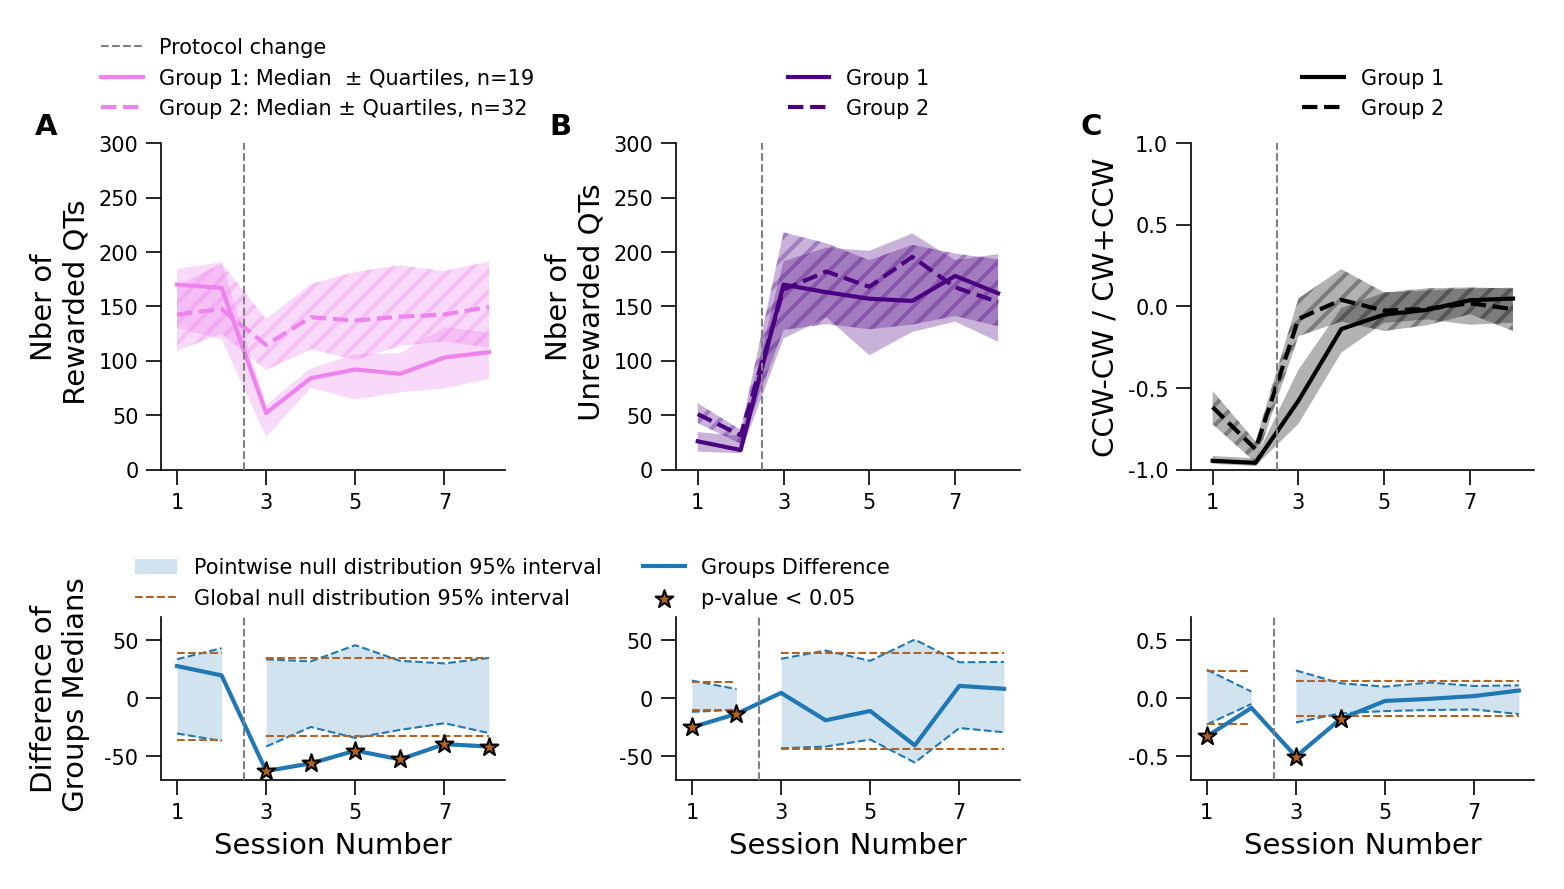

In [17]:
switch_occurence = 2.5

fig=plt.figure(figsize=(cm2inch(15), cm2inch(7)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(2, 1 , hspace=0.6, height_ratios=[1,0.5])

tick_interval = 2

### Upper part ###
row1 = gs[0,0].subgridspec(1, 3, wspace=0.5)

ax_11 = plt.subplot(row1[0])
ax_12 = plt.subplot(row1[1])
ax_13 = plt.subplot(row1[2])

if switch_occurence:
    ax_11.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, label="Protocol change", zorder=999)
    ax_12.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, zorder=999)
    ax_13.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, zorder=999)


#Panel A
plot_learning_curves(mice_rewarded_qts_persession_1, ax_11, mice_to_highlight=illustration_mice_1, show_individual_mice=False, linestyle='-',
                     median_color= 'violet', show_xlabel = False, ylim=[0,300], main_line_label=f'Group 1: Median  \u00B1 Quartiles, n={len(mice_to_analyse_1)}',
                     tick_interval=tick_interval, index_offset=0, show_legend=True)

plot_learning_curves(mice_rewarded_qts_persession_2, ax_11, mice_to_highlight=illustration_mice_2, show_individual_mice=False, linestyle='--',
                     median_color= 'violet', hatch_style='/////', show_xlabel = False, ylim=[0,300], ylabel='Nber of\n Rewarded QTs',
                     main_line_label=f'Group 2: Median \u00B1 Quartiles, n={len(mice_to_analyse_2)}', tick_interval=tick_interval, index_offset=0, show_legend=True, legend_loc=(-0.2,1.05))

fig.text(0.06, 0.9, 'A', weight='bold', va='center', ha='center', fontsize=7)

#Panel B
plot_learning_curves(mice_unrewarded_qts_persession_1, ax_12, mice_to_highlight=illustration_mice_1, show_individual_mice=False, linestyle='-',
                     median_color= 'indigo', show_xlabel = False, ylim=[0,300], main_line_label='Group 1', tick_interval=tick_interval, index_offset=0,
                     show_legend=True)

plot_learning_curves(mice_unrewarded_qts_persession_2, ax_12, mice_to_highlight=illustration_mice_2, show_individual_mice=False, linestyle='--',
                     median_color= 'indigo', hatch_style='/////', xlim=xlim_stats_2, show_xlabel = False, ylim=[0,300], ylabel='Nber of\n Unrewarded QTs',
                     main_line_label='Group 2', tick_interval=tick_interval, index_offset=0, show_legend=True, legend_loc=(0.3,1.05))

fig.text(0.35, 0.9, 'B', weight='bold', va='center', ha='center', fontsize=7)

#Panel C
plot_learning_curves(mice_cw_vs_ccw_norm_diff_persession_1, ax_13, mice_to_highlight=illustration_mice_1, linestyle='-', show_individual_mice=False,
                     show_xlabel = False, ylim=[-1,1], ylabel='CW-CCW / CW+CCW', tick_interval=2, index_offset=0, main_line_label='Group 1', show_legend=True)

plot_learning_curves(mice_cw_vs_ccw_norm_diff_persession_2, ax_13, mice_to_highlight=illustration_mice_2, linestyle='--', hatch_style='/////',
                     show_individual_mice=False, xlim=xlim_stats_2, show_xlabel = False, ylim=[-1,1], ylabel='CCW-CW / CW+CCW', tick_interval=tick_interval,
                     index_offset=0, main_line_label='Group 2', show_legend=True, legend_loc=(0.3,1.05))

fig.text(0.65, 0.9, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Lower row ###
row2 = gs[1,0].subgridspec(1, 3, wspace=0.5)

ax_21 = plt.subplot(row2[0])
ax_22 = plt.subplot(row2[1])
ax_23 = plt.subplot(row2[2])

plot_group_metric_difference(mice_rewarded_qts_persession_1, mice_rewarded_qts_persession_2, ax_21, ylim=[-70,70], ylabel="Difference of\n Groups Medians",
                             tick_interval=tick_interval, legend_loc=[-0.1,1])

plot_group_metric_difference(mice_unrewarded_qts_persession_1, mice_unrewarded_qts_persession_2, ax_22, ylim=[-70,70], tick_interval=tick_interval,
                             show_legend=False)

plot_group_metric_difference(mice_cw_vs_ccw_norm_diff_persession_1, mice_cw_vs_ccw_norm_diff_persession_2, ax_23, ylim=[-0.7,0.7], tick_interval=tick_interval,
                             show_legend=False)

if switch_occurence:
    ax_21.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, zorder=999)
    ax_22.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, zorder=999)
    ax_23.axvline(switch_occurence, linestyle='--', color='grey', linewidth=0.5, zorder=999)

fig.align_ylabels([ax_11,ax_21])

fig.tight_layout()

plt.savefig("FigureS13.png", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="png", dpi=300)


In [18]:
# Save the figure as a PDF
fig.savefig("FigureS13.pdf", format="pdf", bbox_inches='tight', dpi=300)
